## Vizualizace ##

In [14]:
%pip install matplotlib pandas seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [16]:
food_nutrient = pd.read_csv("food_nutrient.csv")

branded_food = pd.read_csv("branded_food.csv")

food_sample_100 = pd.read_csv("food_sample_100.csv")

food_other = pd.read_csv("food_other.csv")

food = pd.concat([food_sample_100, food_other])

food_brands = pd.merge(food, branded_food, on="fdc_id")

top_cat_list = ['Candy', 'Popcorn, Peanuts, Seeds & Related Snacks', 'Cheese', 'Ice Cream & Frozen Yogurt', 'Chips, Pretzels & Snacks', 'Cookies & Biscuits', 'Pickles, Olives, Peppers & Relishes', 'Breads & Buns', 'Fruit & Vegetable Juice, Nectars & Fruit Drinks', 'Snack, Energy & Granola Bars', 'Chocolate', 'Other Snacks']

food_brands = food_brands[food_brands["branded_food_category"].isin(top_cat_list)]

food_brands["branded_food_category"] = food_brands["branded_food_category"].replace({

    "Candy": "Cukrovinky",

    "Popcorn, Peanuts, Seeds & Related Snacks": "Slané snacky",

    "Cheese": "Sýry",

    "Ice Cream & Frozen Yogurt": "Zmrzlina",

    "Chips, Pretzels & Snacks": "Chipsy",

    "Cookies & Biscuits": "Sušenky",

    "Pickles, Olives, Peppers & Relishes": "Nakl. zelenina",

    "Breads & Buns": "Pečivo",

    "Fruit & Vegetable Juice, Nectars & Fruit Drinks": "Džusy",

    "Snack, Energy & Granola Bars": "En. tyčinky",

    "Chocolate": "Čokoláda",

    "Other Snacks": "Další snacky"

})

food_merged_brands = pd.merge(food_brands, food_nutrient, on="fdc_id")

food_merged_brands = food_merged_brands.rename(columns={"name": "nutrient_name"})

food_merged_brands

,fdc_id,data_type,description,food_category_id,publication_date,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,...,data_points,derivation_id,min,max,median,loq,footnote,min_year_acquired,nutrient_name,unit_name
0,1107295,branded_food,"ORIGINAL ROUNDS TORTILLA CHIPS, ORIGINAL",NaN,2020-11-13,Hormel Foods Corporation,NaN,NaN,37600665605,MASA FLOUR (GROUND WHITE CORN WITH A TRACE OF ...,...,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,"Fatty acids, total trans",G
1,1107295,branded_food,"ORIGINAL ROUNDS TORTILLA CHIPS, ORIGINAL",NaN,2020-11-13,Hormel Foods Corporation,NaN,NaN,37600665605,MASA FLOUR (GROUND WHITE CORN WITH A TRACE OF ...,...,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,"Fatty acids, total polyunsaturated",G
2,1107295,branded_food,"ORIGINAL ROUNDS TORTILLA CHIPS, ORIGINAL",NaN,2020-11-13,Hormel Foods Corporation,NaN,NaN,37600665605,MASA FLOUR (GROUND WHITE CORN WITH A TRACE OF ...,...,NaN,75.0,NaN,NaN,NaN,NaN,NaN,NaN,Cholesterol,MG
3,1107295,branded_food,"ORIGINAL ROUNDS TORTILLA CHIPS, ORIGINAL",NaN,2020-11-13,Hormel Foods Corporation,NaN,NaN,37600665605,MASA FLOUR (GROUND WHITE CORN WITH A TRACE OF ...,...,NaN,75.0,NaN,NaN,NaN,NaN,NaN,NaN,"Potassium, K",MG
4,1107295,branded_food,"ORIGINAL ROUNDS TORTILLA CHIPS, ORIGINAL",NaN,2020-11-13,Hormel Foods Corporation,NaN,NaN,37600665605,MASA FLOUR (GROUND WHITE CORN WITH A TRACE OF ...,...,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,Energy,KCAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45949,2662107,branded_food,LIGHT MOZZARELLA LOW-MOISTURE PART-SKIM STRING...,NaN,2023-10-26,Target Stores,MARKET PANTRY,NaN,85239118948,"PASTEURIZED PART-SKIM MILK, CHEESE CULTURES, S...",...,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,"Fiber, total dietary",G
45950,2662107,branded_food,LIGHT MOZZARELLA LOW-MOISTURE PART-SKIM STRING...,NaN,2023-10-26,Target Stores,MARKET PANTRY,NaN,85239118948,"PASTEURIZED PART-SKIM MILK, CHEESE CULTURES, S...",...,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,"Carbohydrate, by difference",G
45951,2662107,branded_food,LIGHT MOZZARELLA LOW-MOISTURE PART-SKIM STRING...,NaN,2023-10-26,Target Stores,MARKET PANTRY,NaN,85239118948,"PASTEURIZED PART-SKIM MILK, CHEESE CULTURES, S...",...,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,Total lipid (fat),G
45952,2662107,branded_food,LIGHT MOZZARELLA LOW-MOISTURE PART-SKIM STRING...,NaN,2023-10-26,Target Stores,MARKET PANTRY,NaN,85239118948,"PASTEURIZED PART-SKIM MILK, CHEESE CULTURES, S...",...,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,Protein,G


In [17]:
# Filtrace záznamů v food_brands, kde sloupec 'branded_food_category' obsahuje hodnoty ze seznamu food_list
food_top_cat = food_brands[food_brands["branded_food_category"].isin(
    food_list)]

# Spojení vyfiltrovaného food_top_cat s food_nutrient na základě sloupce 'fdc_id'
food_brands_nut = pd.merge(food_top_cat, food_nutrient, on="fdc_id")

# Filtrace záznamů, kde 'nutrient_name' má hodnotu 'Protein'
food_merged_brands_protein = food_merged_brands[food_merged_brands["nutrient_name"] == "Protein"]

# Filtrace záznamů, kde 'nutrient_name' je buď 'Protein' nebo 'Lipid (tuk)', a kde 'branded_food_category' má hodnotu 'En. tyčinky'
food_merged_brands_box = food_merged_brands[
    (food_merged_brands["nutrient_name"].isin(["Protein", "Lipid (tuk)"]))
    & (food_merged_brands["branded_food_category"] == "En. tyčinky")
]

## Countplot ##

[Text(0.5, 0, 'Kategorie'),
 Text(0, 0.5, 'Počet potravin'),
 Text(0.5, 1.0, 'Počty potravin ve 12 nejpočetnějších kategoriích')]

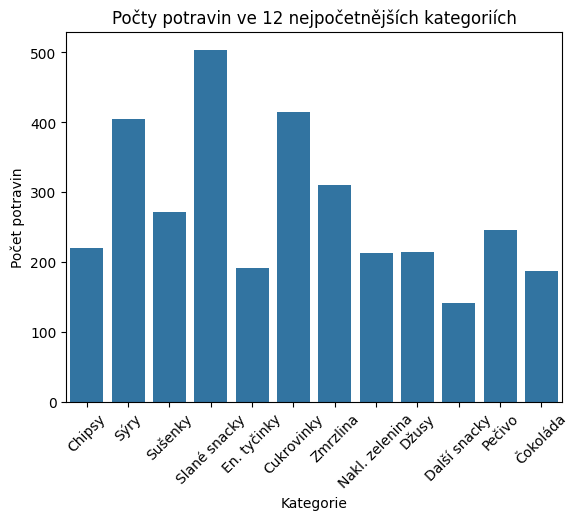

In [18]:
ax = sns.countplot(food_top_cat, x="branded_food_category")

# To switch axes, specify the 'y' parameter instead of 'x'
# ax = sns.countplot(data=food_top_cat, y="branded_food_category")

ax.tick_params(axis="x", rotation=45)
# ax.bar_label(ax.containers[0])
ax.set(
    xlabel="Kategorie",
    ylabel="Počet potravin",
    title="Počty potravin ve 12 nejpočetnějších kategoriích",
)

## Histogram ##

[Text(0.5, 1.0, 'Histogram'),
 Text(0, 0.5, 'Pocet'),
 Text(0.5, 0, 'Mnoztvi proteinu')]

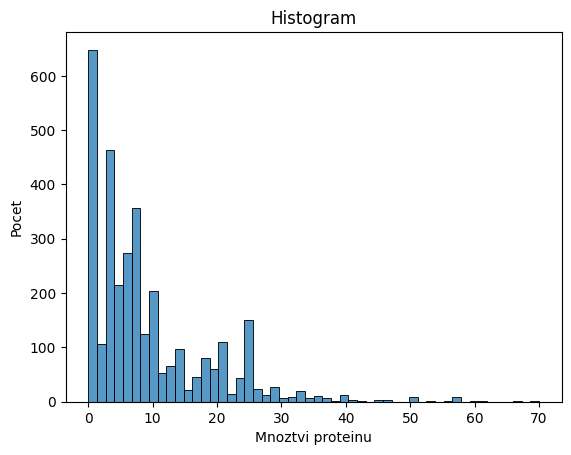

In [19]:
ax = sns.histplot(
    food_merged_brands_protein,
    x="amount",
    # bins=range(0, 100, 10), # list(range(0, 100, 10))
    # color='r',
)

ax.set(title="Histogram", ylabel="Pocet", xlabel="Mnoztvi proteinu")

# plt.title('Histogram', fontsize=24, fontfamily='Arial')

## Barplot ##

[Text(0.5, 0, 'Kategorie'),
 Text(0, 0.5, 'Množství proteinu (g)'),
 Text(0.5, 1.0, 'barchart')]

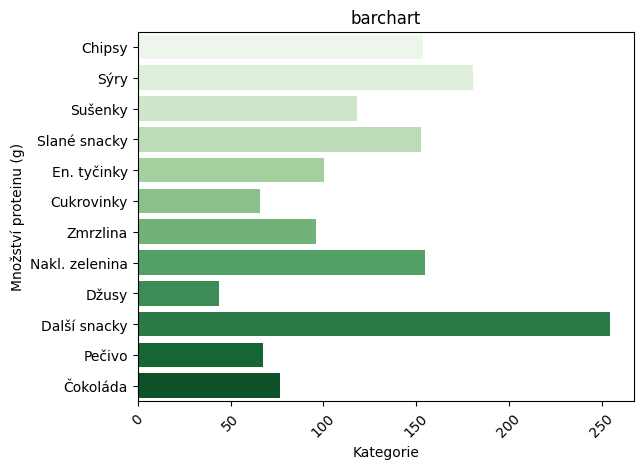

In [20]:
# # Nastavení velikosti grafu
# plt.figure(figsize=(12, 6))

# Vytvoření barového grafu pomocí Seaborn
ax = sns.barplot(
    data=food_brands_nut,
    x="amount",
    y="branded_food_category",
    #  palette="Greens",
    #  hue="branded_food_category",
    errorbar=None,
    palette="Greens",
    hue="branded_food_category"
)

# Nastavení parametrů os a názvu grafu
ax.tick_params(axis="x", rotation=45)
ax.set(
    xlabel="Kategorie",
    ylabel="Množství proteinu (g)",
    title="barchart", #title="Průměrné množství proteinů v potravinách"
)

## Boxplot ##

[Text(0.5, 0, 'Kategorie'),
 Text(0, 0.5, 'Množství v gramech'),
 Text(0.5, 1.0, 'Množství proteinů a lipidů (tuků) v potravinách')]

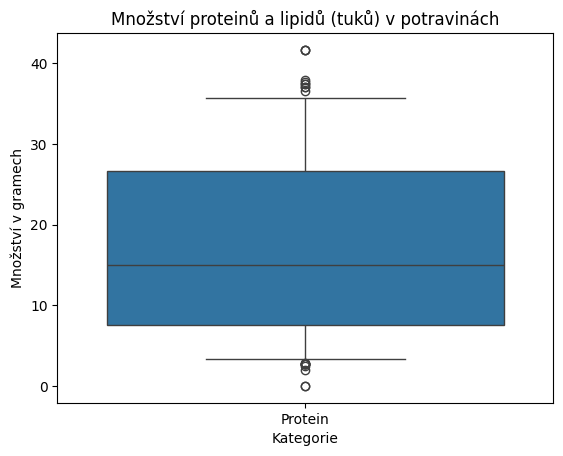

In [21]:
ax = sns.boxplot(
    food_merged_brands_box,
    x="nutrient_name",
    y="amount",
    whis=[5, 95],
    # palette="Blues",
    # hue="nutrient_name",
    # color="yellow",
)

ax.set(
    xlabel="Kategorie",
    ylabel="Množství v gramech",
    title="Množství proteinů a lipidů (tuků) v potravinách",
)

# food_merged_brands_box.groupby("nutrient_name")["amount"].describe()

<Axes: xlabel='amount', ylabel='Count'>

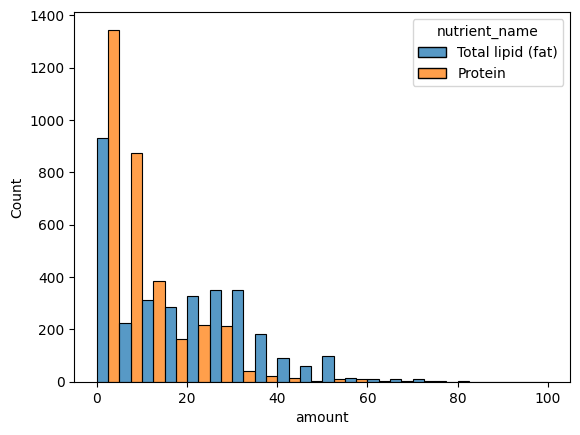

In [22]:
## CVIČENÍ Odstín ##

food_merged_brands_protein_lipid = food_merged_brands[food_merged_brands["nutrient_name"].isin(["Protein","Total lipid (fat)"])]

sns.histplot(food_merged_brands_protein_lipid, x="amount", bins=range(0,105,5), hue = "nutrient_name", multiple = "dodge")

Text(63.77882986111112, 0.5, 'množství látky(g)')

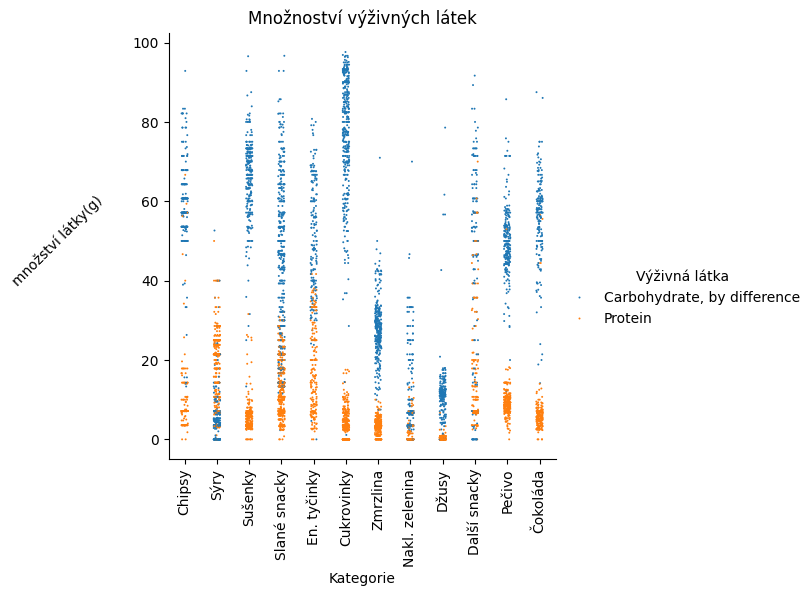

In [23]:
food_merged_brands_protein_carb = food_merged_brands[food_merged_brands["nutrient_name"].isin(["Protein","Carbohydrate, by difference"])]

 

ax = sns.catplot(data = food_merged_brands_protein_carb,

                 x = "branded_food_category",

                 y = "amount",

                 hue = "nutrient_name",

                 s = 2)

ax.tick_params(axis="x", rotation=90)

ax._legend.set_title("Výživná látka")

ax.set(

    xlabel = "Kategorie",

    ylabel = "Množství (g)",

    title= "Množnoství výživných látek" 

)

ax.ax.set_ylabel("množství látky(g)", rotation = 45, labelpad=50)

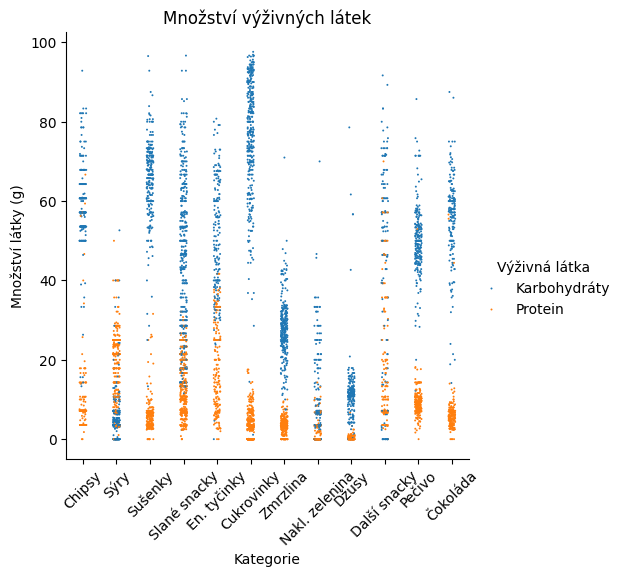

In [24]:
food_merged_brands_protein_carb = food_merged_brands[
    food_merged_brands["nutrient_name"].isin(["Protein", "Carbohydrate, by difference"])]
food_merged_brands_protein_carb["nutrient_name"] = food_merged_brands_protein_carb["nutrient_name"].replace("Carbohydrate, by difference", "Karbohydráty")

ax = sns.catplot(
    data=food_merged_brands_protein_carb,
    x="branded_food_category",
    y="amount",
    hue="nutrient_name",
    s=2,
)
ax.tick_params(axis="x", rotation=45)
ax._legend.set_title("Výživná látka")


ax.set(
    xlabel="Kategorie",
    ylabel="Množství látky (g)",
    title="Množství výživných látek",
)